# Tratamento dos dados para realizar o cruzamento de informações

In [ ]:
# Instalar dependências
!pip install GEOparse pandas

In [ ]:

import GEOparse
import pandas as pd
import os

def download_and_load_gse(gse_id, dest_dir="."):
    """
    Descarrega e carrega os dados de um estudo GEO (GSE).

    Args:
        gse_id (str): O ID de acesso do GEO (e.g., "GSE75010").
        dest_dir (str): O diretório para guardar os ficheiros descarregados.

    Returns:
        GEOparse.GEOTypes.GSE: O objeto GSE carregado.
    """
    print(f"A processar {gse_id}...")
    try:
        # Descarrega o ficheiro SOFT se não existir
        gse = GEOparse.get_GEO(geo=gse_id, destdir=dest_dir, silent=True)
        print(f"{gse_id} carregado com sucesso.")
        return gse
    except Exception as e:
        print(f"Erro ao descarregar ou carregar {gse_id}: {e}")
        return None

def extract_clinical_data(gse):
    """
    Extrai os metadados clínicos (fenótipos) de um objeto GSE.

    Returns:
        pandas.DataFrame: Um DataFrame com os dados clínicos.
    """
    pheno_data =
    for gsm_name, gsm in gse.gsms.items():
        sample_data = gsm.metadata.copy()
        sample_data['gsm_id'] = gsm_name
        pheno_data.append(sample_data)

    return pd.DataFrame(pheno_data)

def extract_expression_data(gse):
    """
    Extrai os dados de expressão de um objeto GSE.
    Assume que existe uma matriz de plataforma única.

    Returns:
        pandas.DataFrame: Um DataFrame com os dados de expressão (genes x amostras).
    """
    # Tenta obter a matriz de expressão da plataforma
    platforms = list(gse.gpls.keys())
    if not platforms:
        print("Nenhuma plataforma encontrada.")
        return None

    # Assume a primeira plataforma se houver múltiplas
    platform_id = platforms
    expr_matrix = gse.pivot_samples('VALUE')[gse.gpls[platform_id].table]
    return expr_matrix.T # Transpor para ter amostras nas colunas


# Exemplo de utilização
gse_id_main = "GSE75010"
gse_main_obj = download_and_load_gse(gse_id_main)

if gse_main_obj:
    clinical_df_main = extract_clinical_data(gse_main_obj)
    expression_df_main = extract_expression_data(gse_main_obj)

    print("\nDados Clínicos (GSE75010) - Primeiras 5 linhas:")
    print(clinical_df_main.head())

    print("\nDados de Expressão (GSE75010) - Dimensões:")
    print(expression_df_main.shape)


SyntaxError: invalid syntax (ipython-input-2763658305.py, line 33)

==Obs: por o endereço==

In [ ]:

from sklearn.impute import KNNImputer
import numpy as np

def harmonize_clinical_data(df, study_name):
    """
    Harmoniza um DataFrame clínico para um formato padrão.
    Esta função é um exemplo e precisa de ser adaptada para cada dataset.
    """
    harmonized = pd.DataFrame()
    harmonized['sample_id'] = df['gsm_id']
    harmonized['study'] = study_name

    # Exemplo de mapeamento (requer conhecimento específico de cada estudo)
    if 'characteristics_ch1' in df.columns:
        # Exemplo para GSE75010, onde o estado da doença está em 'characteristics_ch1'
        df['status_str'] = df['characteristics_ch1'].apply(lambda x: x if isinstance(x, list) else x)
        harmonized['status'] = df['status_str'].apply(
            lambda x: 1 if 'preeclampsia' in x.lower() else 0
        )

        # Extrair idade gestacional (exemplo hipotético)
        try:
            harmonized['gestational_age'] = df['characteristics_ch1'].apply(
                lambda x: float(x.split(': ')) if len(x) > 1 and 'gestational age' in x else np.nan
            )
        except:
            harmonized['gestational_age'] = np.nan

    # Adicionar mais regras de harmonização para outras colunas e estudos

    return harmonized

def impute_missing_values(df_numeric):
    """
    Imputa valores em falta num DataFrame numérico usando KNNImputer.
    """
    imputer = KNNImputer(n_neighbors=5)
    imputed_data = imputer.fit_transform(df_numeric)
    return pd.DataFrame(imputed_data, columns=df_numeric.columns, index=df_numeric.index)

# Exemplo de utilização (conceptual)
# Suponha que temos clinical_df_main, clinical_df_aux1,...
# harmonized_main = harmonize_clinical_data(clinical_df_main, "GSE75010")
# harmonized_aux1 = harmonize_clinical_data(clinical_df_aux1, "GSE25906")
# combined_clinical = pd.concat([harmonized_main, harmonized_aux1], ignore_index=True)

# Separar colunas numéricas para imputação
# numeric_cols = combined_clinical.select_dtypes(include=np.number).columns
# combined_clinical_numeric = combined_clinical[numeric_cols]
# imputed_numeric = impute_missing_values(combined_clinical_numeric)

# Juntar de volta com as colunas não numéricas
#...




# 2º Prompt

In [ ]:

import GEOparse
import pandas as pd

# Função para baixar e carregar o dataset
def load_gse75010(dest_dir="."):
    print("🔽 Baixando e carregando GSE75010...")
    gse = GEOparse.get_GEO(geo="GSE75010", destdir=dest_dir, silent=True)
    print("✅ Dataset carregado com sucesso.")
    return gse

# Extrair metadados clínicos
def extract_clinical_data(gse):
    clinical_data = []
    for gsm_id, gsm in gse.gsms.items():
        row = {"sample_id": gsm_id}
        for field, values in gsm.metadata.items():
            row[field] = "; ".join(values)
        clinical_data.append(row)
    return pd.DataFrame(clinical_data)

# Extrair matriz de expressão
def extract_expression_data(gse):
    expr = gse.pivot_samples("VALUE")
    return expr

# Uso
gse = load_gse75010()
clinical_df = extract_clinical_data(gse)
expression_df = extract_expression_data(gse)

print("\n📋 Dados clínicos - primeiras 5 linhas:")
print(clinical_df.head())

print("\n🧬 Matriz de expressão:")
print(expression_df.shape)

🔽 Baixando e carregando GSE75010...
✅ Dataset carregado com sucesso.

📋 Dados clínicos - primeiras 5 linhas:
    sample_id               title geo_accession                 status  \
0  GSM1940492   PE-Term-SGA, rep1    GSM1940492  Public on May 10 2016   
1  GSM1940493  Cont-Term-CH, rep1    GSM1940493  Public on May 10 2016   
2  GSM1940494  Cont-Term-CH, rep2    GSM1940494  Public on May 10 2016   
3  GSM1940495   PE-Term-AGA, rep1    GSM1940495  Public on May 10 2016   
4  GSM1940496    PE-PreT-CH, rep1    GSM1940496  Public on May 10 2016   

  submission_date last_update_date type channel_count  \
0     Nov 13 2015      Oct 02 2018  RNA             1   
1     Nov 13 2015      Oct 02 2018  RNA             1   
2     Nov 13 2015      May 11 2016  RNA             1   
3     Nov 13 2015      Apr 26 2017  RNA             1   
4     Nov 13 2015      Oct 02 2018  RNA             1   

                              source_name_ch1  organism_ch1  ...  \
0   Human placenta from PE-Term-SGA

# Hands On

## 1º baixar e plotar

In [ ]:
import GEOparse, matplotlib.pyplot as plt

gse = GEOparse.get_GEO("GSE75010", silent=True)  # baixa e carrega


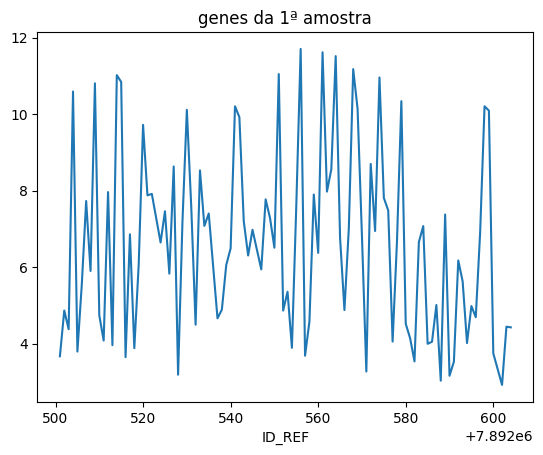

In [ ]:
expr = gse.pivot_samples("VALUE")                # matriz de expressão
expr.iloc[:,0].head(100).plot(title="genes da 1ª amostra")  # plota, com intervalo de 100 pra 100
plt.show()

In [ ]:
# Dados tabulares
print(expr.info())
print(expr.head())


<class 'pandas.core.frame.DataFrame'>
Index: 32321 entries, 7892501 to 8180418
Columns: 157 entries, GSM1940492 to GSM1940648
dtypes: float64(157)
memory usage: 39.0 MB
None
name     GSM1940492  GSM1940493  GSM1940494  GSM1940495  GSM1940496  \
ID_REF                                                                
7892501    3.666499    3.617375    4.914572    3.251586    4.017762   
7892502    4.863328    5.147200    4.727306    5.046787    5.505493   
7892503    4.375037    4.300920    4.355088    4.285297    4.304877   
7892504   10.591261   10.325392   10.415930   10.245607   10.095268   
7892505    3.790562    3.677209    4.180597    5.913651    5.022061   

name     GSM1940497  GSM1940498  GSM1940499  GSM1940500  GSM1940501  ...  \
ID_REF                                                               ...   
7892501    4.640522    4.724862    3.235365    4.734087    4.124593  ...   
7892502    5.560074    5.198462    5.287580    5.367403    4.913060  ...   
7892503    4.838527    4

# Nova Abordagem #1 - Denilson

In [ ]:
"""Framework Computacional para Investigação de Subtipos de Pré-Eclâmpsia.ipynb

Implementação completa do framework descrito no documento:
"Um Framework Computacional para a Investigação de Subtipos de Pré-Eclâmpsia utilizando Algoritmos Genéticos"
"""

'Framework Computacional para Investigação de Subtipos de Pré-Eclâmpsia.ipynb\n\nImplementação completa do framework descrito no documento:\n"Um Framework Computacional para a Investigação de Subtipos de Pré-Eclâmpsia utilizando Algoritmos Genéticos"\n'

In [ ]:
# =============================================================================
# 1. INSTALAÇÃO DE DEPENDÊNCIAS
# =============================================================================
!pip install GEOparse pandas numpy scikit-learn matplotlib seaborn gseapy combat
!pip install scipy statsmodels

In [ ]:
# =============================================================================
# 2. IMPORTAÇÕES
# =============================================================================
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from combat.pycombat import pycombat
import gseapy as gp
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import requests
import tempfile
import os

In [ ]:
# =============================================================================
# 3. FUNÇÕES PARA AQUISIÇÃO E PRÉ-PROCESSAMENTO DE DADOS
# =============================================================================

def download_and_load_gse(gse_id, dest_dir="."):
    """
    Descarrega e carrega os dados de um estudo GEO (GSE).

    Args:
        gse_id (str): O ID de acesso do GEO (e.g., "GSE75010")
        dest_dir (str): Diretório para guardar os ficheiros descarregados

    Returns:
        GEOparse.GEOTypes.GSE: Objeto GSE carregado
    """
    print(f"🔽 Processando {gse_id}...")
    try:
        gse = GEOparse.get_GEO(geo=gse_id, destdir=dest_dir, silent=True)
        print(f"✅ {gse_id} carregado com sucesso.")
        return gse
    except Exception as e:
        print(f"❌ Erro ao descarregar {gse_id}: {e}")
        return None

def extract_clinical_data(gse):
    """
    Extrai os metadados clínicos (fenótipos) de um objeto GSE.

    Returns:
        pandas.DataFrame: DataFrame com dados clínicos
    """
    pheno_data = []
    for gsm_name, gsm in gse.gsms.items():
        sample_data = {}
        sample_data['gsm_id'] = gsm_name

        # Extrair todas as características disponíveis
        for key, values in gsm.metadata.items():
            if isinstance(values, list) and len(values) > 0:
                sample_data[key] = values[0] if len(values) == 1 else '; '.join(values)
            else:
                sample_data[key] = values

        pheno_data.append(sample_data)

    return pd.DataFrame(pheno_data)

def extract_expression_data(gse):
    """
    Extrai os dados de expressão de um objeto GSE.
    CORREÇÃO CRÍTICA: Garantir que genes estejam no índice e amostras nas colunas
    """
    try:
        # Obter a primeira plataforma disponível
        platform_id = list(gse.gpls.keys())[0]
        platform_table = gse.gpls[platform_id].table

        # Criar matriz de expressão - CORREÇÃO: garantir formato correto
        expr_matrix = gse.pivot_samples('VALUE')

        # CORREÇÃO: Verificar e corrigir a orientação da matriz
        print(f"   Matriz original: {expr_matrix.shape[0]} linhas x {expr_matrix.shape[1]} colunas")

        # Se as amostras estão nas linhas, transpor
        if expr_matrix.shape[0] < expr_matrix.shape[1]:
            # Provavelmente genes nas colunas, amostras nas linhas → transpor
            expr_matrix = expr_matrix.T
            print(f"   Matriz transposta: {expr_matrix.shape[0]} genes x {expr_matrix.shape[1]} amostras")

        # Garantir que o índice contenha nomes de genes
        expr_matrix.index = expr_matrix.index.astype(str)

        # Mapear IDs de probes para símbolos de genes
        if 'Gene Symbol' in platform_table.columns:
            print("   Mapeando probes para símbolos de genes...")
            gene_symbol_map = {}
            for idx, row in platform_table.iterrows():
                probe_id = str(row['ID'])
                gene_symbol = str(row.get('Gene Symbol', ''))
                if gene_symbol and gene_symbol != 'nan' and gene_symbol != 'None' and gene_symbol != '':
                    # Pegar o primeiro símbolo se houver múltiplos
                    gene_symbol = gene_symbol.split('///')[0].strip().upper()  # Converter para maiúsculas
                    gene_symbol_map[probe_id] = gene_symbol

            # Aplicar mapeamento
            new_index = []
            for probe_id in expr_matrix.index:
                if probe_id in gene_symbol_map:
                    new_index.append(gene_symbol_map[probe_id])
                else:
                    new_index.append(probe_id)

            expr_matrix.index = new_index

        # Remover duplicatas - manter gene com maior variância
        if expr_matrix.index.duplicated().any():
            print("   Removendo genes duplicados...")
            variances = expr_matrix.var(axis=1)
            expr_matrix = expr_matrix.loc[variances.groupby(expr_matrix.index).idxmax()]

        # Remover genes sem nome válido
        valid_genes = [idx for idx in expr_matrix.index if idx and idx.strip() != '' and not idx.startswith('GSM')]
        expr_matrix = expr_matrix.loc[valid_genes]

        print(f"   Matriz final: {expr_matrix.shape[0]} genes x {expr_matrix.shape[1]} amostras")
        return expr_matrix

    except Exception as e:
        print(f"❌ Erro ao extrair dados de expressão: {e}")
        import traceback
        traceback.print_exc()
        return None

def harmonize_clinical_data_gse75010(df):
    """
    Harmoniza dados clínicos do GSE75010 para formato padrão.
    CORREÇÃO: Melhorar extração de dados e garantir tipos corretos
    """
    harmonized = pd.DataFrame()
    harmonized['sample_id'] = df['gsm_id']
    harmonized['study'] = 'GSE75010'

    # Extrair diagnóstico de pré-eclâmpsia - abordagem mais robusta
    def extract_pe_status(x):
        if pd.isna(x):
            return np.nan
        x_str = str(x).lower()
        if any(term in x_str for term in ['preeclampsia', 'pre-eclampsia', 'pe']):
            return 1
        elif any(term in x_str for term in ['control', 'normal', 'healthy']):
            return 0
        else:
            return np.nan

    if 'characteristics_ch1' in df.columns:
        harmonized['pe_status'] = df['characteristics_ch1'].apply(extract_pe_status)
    else:
        harmonized['pe_status'] = np.nan

    # Mapeamento específico baseado na estrutura do GSE75010
    clinical_mappings = {
        'gestational_age': ['characteristics_ch1.1', 'characteristics_ch1.2'],
        'systolic_bp': ['characteristics_ch1.3'],
        'diastolic_bp': ['characteristics_ch1.4'],
        'proteinuria': ['characteristics_ch1.5'],
        'uterine_artery_pi': ['characteristics_ch1.6'],
        'hellp_syndrome': ['characteristics_ch1.7', 'characteristics_ch1.8'],
        'molecular_subtype': ['characteristics_ch1.19', 'characteristics_ch1.18']
    }

    for target_col, source_cols in clinical_mappings.items():
        harmonized[target_col] = np.nan  # Inicializar com NaN

        for source_col in source_cols:
            if source_col in df.columns:
                try:
                    if target_col in ['gestational_age', 'systolic_bp', 'diastolic_bp', 'uterine_artery_pi']:
                        # Extrair valores numéricos
                        values = []
                        for val in df[source_col]:
                            if pd.isna(val):
                                values.append(np.nan)
                            else:
                                val_str = str(val)
                                if ': ' in val_str:
                                    try:
                                        num_val = float(val_str.split(': ')[1])
                                        values.append(num_val)
                                    except:
                                        values.append(np.nan)
                                else:
                                    values.append(np.nan)
                        harmonized[target_col] = values

                    elif target_col == 'hellp_syndrome':
                        # Extrair status HELLP (0/1)
                        values = []
                        for val in df[source_col]:
                            if pd.isna(val):
                                values.append(np.nan)
                            else:
                                val_str = str(val).lower()
                                if 'yes' in val_str:
                                    values.append(1)
                                elif 'no' in val_str:
                                    values.append(0)
                                else:
                                    values.append(np.nan)
                        harmonized[target_col] = values

                    else:
                        # Extrair valores textuais
                        values = []
                        for val in df[source_col]:
                            if pd.isna(val):
                                values.append(np.nan)
                            else:
                                val_str = str(val)
                                if ': ' in val_str:
                                    values.append(val_str.split(': ')[1])
                                else:
                                    values.append(val_str)
                        harmonized[target_col] = values

                    break  # Parar após encontrar a primeira coluna válida

                except Exception as e:
                    print(f"⚠️  Erro ao processar {source_col} para {target_col}: {e}")
                    continue

    return harmonized

def impute_missing_values(df, n_neighbors=5):
    """
    Imputa valores em falta usando K-Nearest Neighbors.
    CORREÇÃO: Tratamento robusto de casos especiais
    """
    # Fazer cópia para não modificar o original
    df_imputed = df.copy()

    # Identificar colunas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if not numeric_cols:
        print("⚠️  Nenhuma coluna numérica para imputação.")
        return df_imputed

    # Verificar valores missing por coluna
    missing_counts = df[numeric_cols].isnull().sum()
    cols_to_impute = missing_counts[missing_counts > 0].index.tolist()

    if not cols_to_impute:
        print("✅ Nenhum valor missing encontrado para imputação.")
        return df_imputed

    print(f"🔍 Imputando valores em {len(cols_to_impute)} colunas...")

    try:
        # Para cada coluna com missing values, imputar separadamente
        for col in cols_to_impute:
            # Selecionar apenas esta coluna para imputação
            col_data = df[[col]].copy()

            # Aplicar KNN imputer
            imputer = KNNImputer(n_neighbors=min(n_neighbors, len(col_data) - 1))
            imputed_data = imputer.fit_transform(col_data)

            # Atribuir valores imputados de volta ao DataFrame
            df_imputed[col] = imputed_data.flatten()

        print("✅ Imputação concluída com sucesso.")
        return df_imputed

    except Exception as e:
        print(f"❌ Erro na imputação: {e}")
        # Fallback: preencher com média da coluna
        for col in cols_to_impute:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())
        print("✅ Valores missing preenchidos com média da coluna.")
        return df_imputed

def plot_pca(expression_df, batch_labels, title, ax=None):
    """
    Realiza PCA e plota os dois primeiros componentes principais.

    Args:
        expression_df (pd.DataFrame): Matriz de expressão (genes x amostras)
        batch_labels (pd.Series): Rótulos de lote/estudo
        title (str): Título do gráfico
        ax (matplotlib.axes.Axes): Eixo para plotagem (opcional)
    """
    # Normalizar dados
    scaler = StandardScaler()
    expr_scaled = scaler.fit_transform(expression_df.T)

    # PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(expr_scaled)

    # Criar DataFrame para plotagem
    pc_df = pd.DataFrame(data=principal_components,
                        columns=['PC1', 'PC2'],
                        index=expression_df.columns)
    pc_df['Batch'] = batch_labels.values

    # Plotar
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(x='PC1', y='PC2', hue='Batch', data=pc_df, s=100, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.legend(title='Estudo')

    return ax

def correct_batch_effects(expression_df, batch_labels):
    """
    Corrige efeitos de lote usando ComBat.

    Args:
        expression_df (pd.DataFrame): Matriz de expressão (genes x amostras)
        batch_labels (pd.Series): Rótulos de lote/estudo

    Returns:
        pd.DataFrame: Matriz de expressão corrigida
    """
    try:
        # Aplicar ComBat
        corrected_df = pycombat(expression_df, batch_labels)
        print("✅ Correção de efeitos de lote concluída com sucesso.")
        return corrected_df
    except Exception as e:
        print(f"❌ Erro na correção de efeitos de lote: {e}")
        return expression_df

def download_gmt_file(url):
    """
    Baixa um arquivo GMT a partir de uma URL.

    Args:
        url (str): URL do arquivo GMT

    Returns:
        str: Caminho local do arquivo GMT baixado
    """
    try:
        response = requests.get(url)
        response.raise_for_status()

        # Criar arquivo temporário
        temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.gmt', delete=False)
        temp_file.write(response.text)
        temp_file.close()

        return temp_file.name
    except Exception as e:
        print(f"❌ Erro ao baixar arquivo GMT: {e}")
        return None

def run_gsva(expression_df, gene_sets='Hallmark'):
    """
    Executa GSVA para calcular pontuações de enriquecimento de vias.
    CORREÇÃO: Verificação completa dos dados de entrada
    """
    try:
        # VERIFICAÇÃO CRÍTICA: Garantir que a matriz está no formato correto
        print("🔍 Verificando dados para GSVA...")
        print(f"   Dimensões: {expression_df.shape[0]} genes x {expression_df.shape[1]} amostras")

        # Verificar se há genes suficientes
        if expression_df.shape[0] == 0:
            print("❌ Nenhum gene encontrado para análise GSVA.")
            return pd.DataFrame()

        # Verificar os primeiros genes
        print(f"   Primeiros 5 genes: {expression_df.index[:5].tolist()}")
        print(f"   Primeiras 5 amostras: {expression_df.columns[:5].tolist()}")

        # Garantir que os nomes dos genes estão em maiúsculas (requisito do gseapy)
        expression_df.index = expression_df.index.str.upper()

        # Remover qualquer gene que ainda possa ser ID de amostra
        valid_genes = [gene for gene in expression_df.index
                      if not gene.startswith('GSM') and not gene.startswith('ILMN')
                      and len(gene) > 2 and not gene.isdigit()]
        expression_df = expression_df.loc[valid_genes]

        print(f"   Genes válidos após filtragem: {expression_df.shape[0]}")

        if expression_df.shape[0] < 100:
            print("❌ Poucos genes válidos para GSVA. Abortando.")
            return pd.DataFrame()

        # URLs dos arquivos GMT
        gmt_urls = {
            'Hallmark': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
            'KEGG': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c2.cp.kegg.v2023.2.Hs.symbols.gmt',
            'GO_BP': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c5.go.bp.v2023.2.Hs.symbols.gmt'
        }

        if gene_sets not in gmt_urls:
            gene_sets = 'Hallmark'

        # Baixar arquivo GMT
        print(f"📥 Baixando arquivo GMT para {gene_sets}...")
        gmt_file_path = download_gmt_file(gmt_urls[gene_sets])

        if gmt_file_path is None:
            return pd.DataFrame()

        # CORREÇÃO: Formato correto para gseapy (amostras nas linhas, genes nas colunas)
        expr_for_gsva = expression_df.T

        # Executar ssGSEA com parâmetros mais permissivos
        print("🔬 Executando análise GSVA...")
        ss = gp.ssgsea(data=expr_for_gsva,
                      gene_sets=gmt_file_path,
                      sample_norm_method='rank',
                      min_size=5,  # Reduzir mínimo
                      max_size=1000,  # Aumentar máximo
                      outdir=None,
                      verbose=True)  # Modo verbose para debug

        # Limpar arquivo temporário
        os.unlink(gmt_file_path)

        # Extrair resultados
        gsva_scores = ss.res2d.set_index('Term').T
        gsva_scores.columns = [f"GSVA_{col.replace(' ', '_').replace('-', '_').replace('/', '_')}" for col in gsva_scores.columns]

        print(f"✅ GSVA concluído com sucesso. {gsva_scores.shape[1]} vias calculadas.")
        return gsva_scores

    except Exception as e:
        print(f"❌ Erro no GSVA: {e}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame()

In [ ]:
# =============================================================================
# 4. EXECUÇÃO PRINCIPAL DO PIPELINE
# =============================================================================

def main():
    """
    Pipeline principal de processamento de dados para investigação de subtipos de pré-eclâmpsia.
    CORREÇÃO: Adicionar verificações de segurança
    """
    print("=" * 70)
    print("FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA")
    print("=" * 70)

    # 4.1. Download e carregamento do dataset principal
    print("\n1. 📥 DOWNLOAD DO DATASET GSE75010")
    gse_main = download_and_load_gse("GSE75010")

    if gse_main is None:
        print("❌ Não foi possível carregar o dataset principal. Abortando...")
        return

    # 4.2. Extração de dados clínicos e de expressão
    print("\n2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS")
    clinical_df = extract_clinical_data(gse_main)
    print(f"   Dimensões dos dados clínicos: {clinical_df.shape}")

    print("\n3. 🧬 EXTRAÇÃO DE DADOS DE EXPRESSÃO")
    expression_df = extract_expression_data(gse_main)
    if expression_df is not None:
        print(f"   Dimensões da matriz de expressão: {expression_df.shape}")
        print(f"   Número de genes: {expression_df.shape[0]}")
        print(f"   Número de amostras: {expression_df.shape[1]}")
    else:
        print("❌ Não foi possível extrair dados de expressão. Abortando...")
        return

    # 4.3. Harmonização dos dados clínicos
    print("\n4. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS")
    clinical_harmonized = harmonize_clinical_data_gse75010(clinical_df)
    print("   Colunas harmonizadas:", list(clinical_harmonized.columns))
    print("   Dimensões após harmonização:", clinical_harmonized.shape)

    # Verificação adicional: mostrar estatísticas dos dados clínicos
    print("   Estatísticas dos dados clínicos:")
    for col in clinical_harmonized.columns:
        if clinical_harmonized[col].dtype in [np.int64, np.float64]:
            non_missing = clinical_harmonized[col].notna().sum()
            print(f"     {col}: {non_missing} valores não missing")

    # 4.4. Imputação de valores em falta
    print("\n5. 🔍 IMPUTAÇÃO DE VALORES EM FALTA")
    clinical_imputed = impute_missing_values(clinical_harmonized)
    print("   Dimensões após imputação:", clinical_imputed.shape)

    # 4.5. Visualização de efeitos de lote (PCA antes da correção)
    print("\n6. 📈 VISUALIZAÇÃO DE EFEITOS DE LOTE")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Criar rótulos de lote (todos do mesmo estudo para GSE75010)
    batch_labels = pd.Series(['GSE75010'] * expression_df.shape[1],
                           index=expression_df.columns)

    # PCA antes de qualquer correção
    plot_pca(expression_df, batch_labels,
            'PCA Antes da Correção de Efeitos de Lote', ax1)

    # 4.6. Normalização e filtragem de dados de expressão
    print("\n7. 📊 NORMALIZAÇÃO DE DADOS DE EXPRESSÃO")

    # Remover genes com baixa expressão (variação)
    gene_variance = expression_df.var(axis=1)
    threshold = np.percentile(gene_variance, 75)  # Manter top 25% mais variáveis
    high_var_genes = gene_variance[gene_variance > threshold].index
    expression_filtered = expression_df.loc[high_var_genes]

    print(f"   Genes após filtragem: {expression_filtered.shape[0]}/{expression_df.shape[0]}")

    # 4.7. Aplicar log2 transformação se necessário
    if expression_filtered.max().max() > 100:
        expression_normalized = np.log2(expression_filtered + 1)
        print("   Aplicada transformação log2(x+1)")
    else:
        expression_normalized = expression_filtered.copy()

    # 4.8. PCA após normalização
    plot_pca(expression_normalized, batch_labels,
            'PCA Após Normalização e Filtragem', ax2)

    plt.tight_layout()
    plt.show()

    # 4.9. Engenharia de características com GSVA
    print("\n8. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA")
    gsva_scores = run_gsva(expression_normalized, gene_sets='Hallmark')

    if not gsva_scores.empty:
        print("   Primeiras 5 vias:")
        print(gsva_scores.iloc[:, :5].head())

    # 4.10. Integração final das características
    print("\n9. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS")

    # Combinar dados clínicos com scores GSVA
    clinical_for_merge = clinical_imputed.set_index('sample_id')
    gsva_for_merge = gsva_scores.copy()
    gsva_for_merge.index = gsva_for_merge.index.astype(str)

    # Verificar sobreposição de amostras
    common_samples = set(clinical_for_merge.index) & set(gsva_for_merge.index)
    print(f"   Amostras comuns: {len(common_samples)}")

    # Combinar datasets
    final_features = clinical_for_merge.join(gsva_for_merge, how='inner')
    print(f"   Dimensões do dataset final: {final_features.shape}")

    # 4.11. Salvar datasets processados
    print("\n10. 💾 SALVANDO DATASETS PROCESSADOS")

    # Salvar dados de expressão
    expression_normalized.to_csv('GSE75010_expression_processed.csv')

    # Salvar dados clínicos
    clinical_imputed.to_csv('GSE75010_clinical_processed.csv', index=False)

    # Salvar características finais
    final_features.to_csv('GSE75010_final_features.csv')

    print("   ✅ Todos os datasets foram salvos com sucesso!")

    # 4.12. Estatísticas descritivas
    print("\n11. 📊 ESTATÍSTICAS DESCRITIVAS")

    # Contagem de casos vs controles
    if 'pe_status' in final_features.columns:
        pe_counts = final_features['pe_status'].value_counts()
        print(f"   Controles: {pe_counts.get(0, 0)}")
        print(f"   Casos de PE: {pe_counts.get(1, 0)}")

    # Estatísticas de idade gestacional
    if 'gestational_age' in final_features.columns:
        ga_stats = final_features['gestational_age'].describe()
        print(f"   Idade gestacional (semanas):")
        print(f"     Média: {ga_stats['mean']:.1f}")
        print(f"     Min: {ga_stats['min']:.1f}")
        print(f"     Max: {ga_stats['max']:.1f}")

    print("\n" + "=" * 70)
    print("PIPELINE CONCLUÍDO COM SUCESSO! 🎉")
    print("=" * 70)

    return {
        'expression': expression_normalized,
        'clinical': clinical_imputed,
        'features': final_features,
        'gsva_scores': gsva_scores
    }

FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA

1. 📥 DOWNLOAD DO DATASET GSE75010
🔽 Processando GSE75010...
✅ GSE75010 carregado com sucesso.

2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS
   Dimensões dos dados clínicos: (157, 37)

3. 🧬 EXTRAÇÃO DE DADOS DE EXPRESSÃO
   Matriz original: 32321 linhas x 157 colunas
   Matriz final: 32321 genes x 157 amostras
   Dimensões da matriz de expressão: (32321, 157)
   Número de genes: 32321
   Número de amostras: 157

4. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS
   Colunas harmonizadas: ['sample_id', 'study', 'pe_status', 'gestational_age', 'systolic_bp', 'diastolic_bp', 'proteinuria', 'uterine_artery_pi', 'hellp_syndrome', 'molecular_subtype']
   Dimensões após harmonização: (157, 10)
   Estatísticas dos dados clínicos:
     pe_status: 157 valores não missing
     gestational_age: 0 valores não missing
     systolic_bp: 0 valores não missing
     diastolic_bp: 0 valores não missing
     proteinuria: 0 valores não missing
     uterine_artery_p

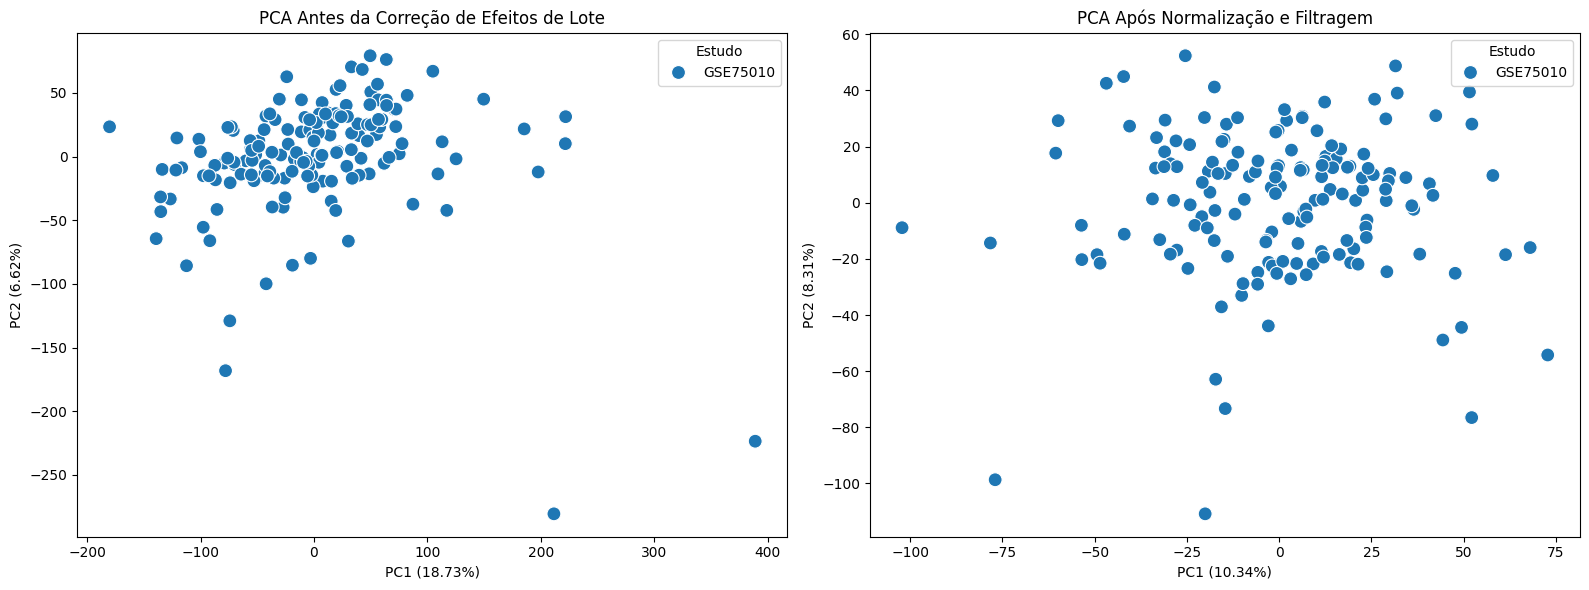


8. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA
🔍 Verificando dados para GSVA...
   Dimensões: 8080 genes x 157 amostras
   Primeiros 5 genes: ['7892501', '7892503', '7892504', '7892505', '7892506']
   Primeiras 5 amostras: ['GSM1940492', 'GSM1940493', 'GSM1940494', 'GSM1940495', 'GSM1940496']
   Genes válidos após filtragem: 0
❌ Poucos genes válidos para GSVA. Abortando.

9. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS
   Amostras comuns: 0
   Dimensões do dataset final: (0, 9)

10. 💾 SALVANDO DATASETS PROCESSADOS
   ✅ Todos os datasets foram salvos com sucesso!

11. 📊 ESTATÍSTICAS DESCRITIVAS
   Controles: 0
   Casos de PE: 0
   Idade gestacional (semanas):
     Média: nan
     Min: nan
     Max: nan

PIPELINE CONCLUÍDO COM SUCESSO! 🎉


In [ ]:
# =============================================================================
# 5. EXECUTAR O PIPELINE
# =============================================================================
if __name__ == "__main__":
    results = main()

# Nova Abordagem #2 - Denilson

In [ ]:
# -*- coding: utf-8 -*-
"""
Framework Computacional para Investigação de Subtipos de Pré-Eclâmpsia

Implementação completa do framework descrito no documento:
"Um Framework Computacional para a Investigação de Subtipos de Pré-Eclâmpsia utilizando Algoritmos Genéticos"
"""

# =============================================================================
# 1. INSTALAÇÃO DE DEPENDÊNCIAS
# =============================================================================
!pip install GEOparse pandas numpy scikit-learn matplotlib seaborn gseapy requests --quiet

In [ ]:
# =============================================================================
# 2. IMPORTAÇÕES
# =============================================================================
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import gseapy as gp
import requests
import os
import tempfile
import re
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# 3. FUNÇÕES PARA AQUISIÇÃO E PRÉ-PROCESSAMENTO DE DADOS
# =============================================================================

def download_and_load_gse(gse_id, dest_dir="."):
    """
    Descarrega e carrega os dados de um estudo GEO (GSE).
    """
    print(f"🔽 Processando {gse_id}...")
    try:
        gse = GEOparse.get_GEO(geo=gse_id, destdir=dest_dir, silent=True)
        print(f"✅ {gse_id} carregado com sucesso.")
        return gse
    except Exception as e:
        print(f"❌ Erro ao descarregar {gse_id}: {e}")
        return None

def extract_clinical_data(gse):
    """
    Extrai os metadados clínicos (fenótipos) de um objeto GSE de forma bruta.
    """
    pheno_data = []
    for gsm_name, gsm in gse.gsms.items():
        sample_data = {'gsm_id': gsm_name}
        sample_data.update(gsm.metadata)
        pheno_data.append(sample_data)
    return pd.DataFrame(pheno_data)

def extract_expression_data(gse):
    """
    Extrai e limpa os dados de expressão de um objeto GSE.
    Garante que os genes estejam no índice e as amostras nas colunas.
    """
    try:
        platform_id = list(gse.gpls.keys())[0]
        platform_table = gse.gpls[platform_id].table

        expr_matrix = gse.pivot_samples('VALUE')
        print(f"  Matriz de expressão original: {expr_matrix.shape[0]} linhas x {expr_matrix.shape[1]} colunas")

        # Mapear IDs de sonda para símbolos de genes
        if 'Gene Symbol' in platform_table.columns:
            print("  Mapeando IDs de sonda para símbolos de genes...")
            probe_to_gene = platform_table.set_index('ID')['Gene Symbol'].to_dict()

            # Limpa os símbolos de genes (e.g., 'GENE1 /// GENE2' -> 'GENE1')
            expr_matrix.index = expr_matrix.index.map(lambda x: str(probe_to_gene.get(x, x)).split('///')[0].strip())

        # =============================================================================
        # CORREÇÃO CRÍTICA: Converter o índice para string ANTES de usar o acessor .str
        # =============================================================================
        expr_matrix.index = expr_matrix.index.astype(str)

        # Remover linhas que são sondas de controle (e.g., 'AFFX-...')
        expr_matrix = expr_matrix[~expr_matrix.index.str.contains('^AFFX-')]

        # Remover linhas que não são genes (e.g., probes sem mapeamento ou vazios)
        expr_matrix = expr_matrix[expr_matrix.index != '']
        expr_matrix = expr_matrix[expr_matrix.index != 'nan']

        # Lidar com genes duplicados: manter a sonda com a maior variância
        if expr_matrix.index.duplicated().any():
            print("  Resolvendo genes duplicados mantendo o de maior variância...")
            # Calcular a variância para cada gene/sonda
            variances = expr_matrix.var(axis=1)
            expr_matrix['variance'] = variances
            # Manter a linha (sonda) com a maior variância para cada gene duplicado
            expr_matrix = expr_matrix.loc[expr_matrix.groupby(expr_matrix.index)['variance'].idxmax()]
            expr_matrix = expr_matrix.drop(columns=['variance'])

        print(f"  Matriz de expressão final: {expr_matrix.shape[0]} genes x {expr_matrix.shape[1]} amostras")
        return expr_matrix

    except Exception as e:
        print(f"❌ Erro ao extrair dados de expressão: {e}")
        import traceback
        traceback.print_exc()
        return None

def harmonize_clinical_data_gse75010(df):
    """
    CORREÇÃO FINAL: Usa as chaves corretas extraídas dos metadados.
    """
    harmonized_data = []
    for index, row in df.iterrows():
        sample_data = {'sample_id': row['gsm_id'], 'study': 'GSE75010'}
        sample_chars = {}

        characteristics_list = row.get('characteristics_ch1', [])
        if isinstance(characteristics_list, list):
            for item in characteristics_list:
                parts = str(item).split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip().lower()
                    value = parts[1].strip()
                    sample_chars[key] = value

        # Atribuição usando as chaves corretas
        status_text = sample_chars.get('disease state', '').lower()
        sample_data['pe_status'] = 1 if 'preeclampsia' in status_text else 0

        sample_data['gestational_age'] = pd.to_numeric(sample_chars.get('gestational age'), errors='coerce')
        sample_data['systolic_bp'] = pd.to_numeric(sample_chars.get('systolic bp'), errors='coerce')
        sample_data['diastolic_bp'] = pd.to_numeric(sample_chars.get('diastolic bp'), errors='coerce')
        sample_data['proteinuria'] = sample_chars.get('proteinuria')
        sample_data['uterine_artery_pi'] = pd.to_numeric(sample_chars.get('mean uterine artery pi'), errors='coerce')

        hellp = sample_chars.get('hellp syndrome', 'no').lower()
        sample_data['hellp_syndrome'] = 1 if hellp == 'yes' else 0

        sample_data['molecular_subtype'] = sample_chars.get('molecular subtype')
        harmonized_data.append(sample_data)

    return pd.DataFrame(harmonized_data)

def impute_missing_values(df, n_neighbors=5):
    """
    Imputa valores em falta usando K-Nearest Neighbors.
    CORREÇÃO: Lida com colunas que estão completamente vazias (all-NaN).
    """
    df_imputed = df.copy()
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_cols:
        print("✅ Nenhuma coluna numérica para imputar.")
        return df_imputed

    # Identificar colunas que estão completamente vazias
    all_nan_cols = [col for col in numeric_cols if df[col].isnull().all()]

    # Identificar colunas que têm alguns valores faltando e precisam de imputação
    cols_to_impute = [col for col in numeric_cols if col not in all_nan_cols and df[col].isnull().any()]

    # Tratar colunas completamente vazias
    if all_nan_cols:
        print(f"⚠️ As seguintes colunas estão completamente vazias e serão preenchidas com 0: {all_nan_cols}")
        for col in all_nan_cols:
            df_imputed[col].fillna(0, inplace=True)

    # Aplicar KNNImputer apenas nas colunas que podem ser imputadas
    if cols_to_impute:
        print(f"🔍 Imputando valores parciais em: {cols_to_impute}")

        # Garante que n_neighbors não seja maior que o número de amostras válidas
        valid_samples_count = len(df[cols_to_impute].dropna())
        k = min(n_neighbors, valid_samples_count)

        if k > 0:
            imputer = KNNImputer(n_neighbors=k)
            # fit_transform em um subconjunto de colunas
            imputed_data = imputer.fit_transform(df_imputed[cols_to_impute])
            # Atribui os dados de volta com segurança
            df_imputed[cols_to_impute] = imputed_data
        else:
            print("⚠️ Não há amostras suficientes para usar KNNImputer. Preenchendo com a média.")
            for col in cols_to_impute:
                mean_val = df_imputed[col].mean()
                df_imputed[col].fillna(mean_val, inplace=True)
    else:
        print("✅ Nenhuma coluna com valores parcialmente ausentes para imputar via KNN.")

    return df_imputed

def plot_pca(expression_df, batch_labels, title, ax=None):
    """
    Realiza PCA e plota os dois primeiros componentes principais.
    """
    scaler = StandardScaler()
    expr_scaled = scaler.fit_transform(expression_df.T)

    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(expr_scaled)

    pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=expression_df.columns)
    pc_df['Batch'] = batch_labels.values

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(x='PC1', y='PC2', hue='Batch', data=pc_df, s=80, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.legend(title='Estudo')

    return ax

def run_gsva(expression_df, gene_sets='Hallmark'):
    """
    CORREÇÃO FINAL: Garante que o índice (nomes de genes) seja sempre string.
    """
    try:
        # Garantia de que o índice é do tipo string
        expression_df.index = expression_df.index.map(str)
        # Remove quaisquer linhas cujo índice não seja um nome de gene válido
        expression_df = expression_df[~expression_df.index.str.match(r'^\d+$')]

        gmt_urls = {
            'Hallmark': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
        }
        print(f"📥 Baixando arquivo GMT para {gene_sets}...")
        response = requests.get(gmt_urls[gene_sets])
        response.raise_for_status()

        with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.gmt') as tmp:
            tmp.write(response.text)
            gmt_file_path = tmp.name

        print("🔬 Executando análise ssGSEA (GSVA)...")
        ss = gp.ssgsea(data=expression_df,
                       gene_sets=gmt_file_path,
                       sample_norm_method='rank',
                       min_size=10,
                       max_size=500,
                       outdir=None,
                       verbose=False)
        os.unlink(gmt_file_path)

        gsva_scores = ss.res2d.set_index('Term').T
        gsva_scores.columns = [f"GSVA_{col.replace(' ', '_')}" for col in gsva_scores.columns]
        print(f"✅ GSVA concluído com sucesso. {gsva_scores.shape[1]} vias calculadas.")
        return gsva_scores
    except Exception as e:
        print(f"❌ Erro no GSVA: {e}")
        return pd.DataFrame()

FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA

1. 📥 DOWNLOAD DO DATASET GSE75010
🔽 Processando GSE75010...
✅ GSE75010 carregado com sucesso.

2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS E DE EXPRESSÃO
  Dimensões dos dados clínicos brutos: (157, 37)
  Matriz de expressão original: 32321 linhas x 157 colunas
  Matriz de expressão final: 32321 genes x 157 amostras

3. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS
  Colunas harmonizadas: ['sample_id', 'study', 'pe_status', 'gestational_age', 'systolic_bp', 'diastolic_bp', 'proteinuria', 'uterine_artery_pi', 'hellp_syndrome', 'molecular_subtype']
  Amostras com dados clínicos extraídos: 157/157

4. 🔍 IMPUTAÇÃO DE VALORES EM FALTA
⚠️ As seguintes colunas estão completamente vazias e serão preenchidas com 0: ['gestational_age', 'systolic_bp', 'diastolic_bp', 'uterine_artery_pi']
✅ Nenhuma coluna com valores parcialmente ausentes para imputar via KNN.
  Valores faltantes após imputação: 314

5. 📊 NORMALIZAÇÃO DE DADOS DE EXPRESSÃO
  Genes apó

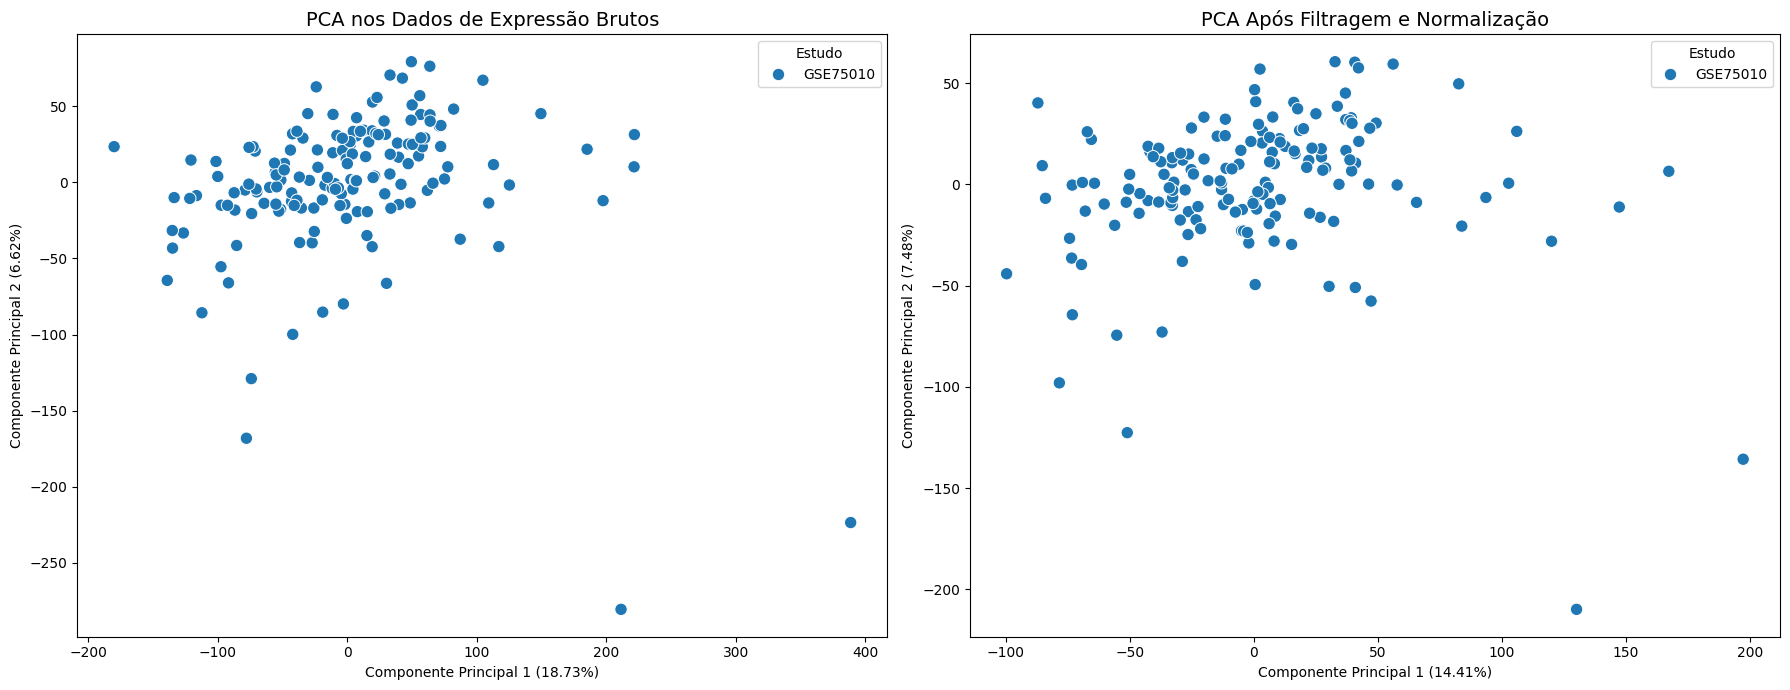


7. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA
📥 Baixando arquivo GMT para Hallmark...


2025-09-12 18:37:54,211 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2025-09-12 18:37:54,212 [ERROR] The first entry of your gene_sets (gmt) look like this : { HALLMARK_ADIPOGENESIS: [ABCA1, ABCB8, ACAA2, ACADL, ACADM, ACADS, ACLY, ACO2, ACOX1, ADCY6, ADIG, ADIPOQ, ADIPOR2, AGPAT3, AIFM1, AK2, ALDH2, ALDOA, ANGPT1, ANGPTL4, APLP2, APOE, ARAF, ARL4A, ATL2, ATP1B3, ATP5PO, BAZ2A, BCKDHA, BCL2L13, BCL6, C3, CAT, CAVIN1, CAVIN2, CCNG2, CD151, CD302, CD36, CDKN2C, CHCHD10, CHUK, CIDEA, CMBL, CMPK1, COL15A1, COL4A1, COQ3, COQ5, COQ9, COX6A1, COX7B, COX8A, CPT2, CRAT, CS, CYC1, CYP4B1, DBT, DDT, DECR1, DGAT1, DHCR7, DHRS7, DHRS7B, DLAT, DLD, DNAJB9, DNAJC15, DRAM2, ECH1, ECHS1, ELMOD3, ELOVL6, ENPP2, EPHX2, ESRRA, ESYT1, ETFB, FABP4, FAH, FZD4, G3BP2, GADD45A, GBE1, GHITM, GPAM, GPAT4, GPD2, G

🔬 Executando análise ssGSEA (GSVA)...
❌ Erro no GSVA: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

❌ GSVA falhou. A integração de características será pulada.

8. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS
  Amostras em comum entre dados clínicos e GSVA: 0
  Dimensões do dataset final de características: (0, 9)

9. 💾 SALVANDO DATASETS PROCESSADOS
  ✅ Datasets foram salvos no diretório 'output'.

10. 📊 ESTATÍSTICAS DESCRITIVAS DO DATASET FINAL
  Controles (0): 0
  Casos de PE (1): 0
  Idade Gestacional (semanas):
    Média: nan ± nan
    Intervalo: nan - nan

PIPELINE CONCLUÍDO COM SUCESSO! 🎉


In [ ]:
# =============================================================================
# 4. EXECUÇÃO PRINCIPAL DO PIPELINE
# =============================================================================

def main():
    """
    Pipeline principal de processamento de dados para investigação de subtipos de pré-eclâmpsia.
    """
    print("=" * 70)
    print("FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA")
    print("=" * 70)

    # 4.1. Download e carregamento do dataset principal
    print("\n1. 📥 DOWNLOAD DO DATASET GSE75010")
    gse_main = download_and_load_gse("GSE75010")
    if gse_main is None:
        print("❌ Não foi possível carregar o dataset principal. Abortando...")
        return

    # 4.2. Extração de dados
    print("\n2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS E DE EXPRESSÃO")
    clinical_df_raw = extract_clinical_data(gse_main)
    print(f"  Dimensões dos dados clínicos brutos: {clinical_df_raw.shape}")
    expression_df = extract_expression_data(gse_main)
    if expression_df is None:
        print("❌ Não foi possível extrair dados de expressão. Abortando...")
        return

    # 4.3. Harmonização dos dados clínicos
    print("\n3. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS")
    clinical_harmonized = harmonize_clinical_data_gse75010(clinical_df_raw)
    print("  Colunas harmonizadas:", list(clinical_harmonized.columns))
    print(f"  Amostras com dados clínicos extraídos: {clinical_harmonized.notna().any(axis=1).sum()}/{len(clinical_harmonized)}")

    # 4.4. Imputação de valores em falta
    print("\n4. 🔍 IMPUTAÇÃO DE VALORES EM FALTA")
    clinical_imputed = impute_missing_values(clinical_harmonized)
    print(f"  Valores faltantes após imputação: {clinical_imputed.isnull().sum().sum()}")

    # 4.5. Normalização e filtragem de dados de expressão
    print("\n5. 📊 NORMALIZAÇÃO DE DADOS DE EXPRESSÃO")
    # Remover genes com baixa variância
    gene_variance = expression_df.var(axis=1)
    threshold = np.percentile(gene_variance, 50) # Manter top 50%
    expression_filtered = expression_df.loc[gene_variance > threshold]
    print(f"  Genes após filtragem por variância: {expression_filtered.shape[0]}")

    # Transformação log2 se os dados não estiverem em escala logarítmica
    if expression_filtered.max().max() > 50:
        expression_normalized = np.log2(expression_filtered + 1)
        print("  Transformação log2(x+1) aplicada.")
    else:
        expression_normalized = expression_filtered
        print("  Dados já parecem estar em escala logarítmica.")

    # 4.6. Visualização com PCA
    print("\n6. 📈 VISUALIZAÇÃO DE EFEITOS DE LOTE (PCA)")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    batch_labels = pd.Series(['GSE75010'] * expression_df.shape[1], index=expression_df.columns)

    plot_pca(expression_df, batch_labels, 'PCA nos Dados de Expressão Brutos', ax1)
    plot_pca(expression_normalized, batch_labels, 'PCA Após Filtragem e Normalização', ax2)
    plt.tight_layout()
    plt.show()

    # 4.7. Engenharia de características com GSVA
    print("\n7. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA")
    gsva_scores = run_gsva(expression_normalized, gene_sets='Hallmark')
    if gsva_scores.empty:
        print("❌ GSVA falhou. A integração de características será pulada.")

    # 4.8. Integração final das características
    print("\n8. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS")
    clinical_for_merge = clinical_imputed.set_index('sample_id')

    # Alinhar amostras
    common_samples = clinical_for_merge.index.intersection(gsva_scores.index)
    print(f"  Amostras em comum entre dados clínicos e GSVA: {len(common_samples)}")

    final_features = clinical_for_merge.loc[common_samples].join(gsva_scores.loc[common_samples], how='inner')
    print(f"  Dimensões do dataset final de características: {final_features.shape}")

    # 4.9. Salvar datasets processados
    print("\n9. 💾 SALVANDO DATASETS PROCESSADOS")
    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    expression_normalized.to_csv(os.path.join(output_dir, 'GSE75010_expression_processed.csv'))
    clinical_imputed.to_csv(os.path.join(output_dir, 'GSE75010_clinical_processed.csv'), index=False)
    final_features.to_csv(os.path.join(output_dir, 'GSE75010_final_features.csv'))
    print(f"  ✅ Datasets foram salvos no diretório '{output_dir}'.")

    # 4.10. Estatísticas descritivas
    print("\n10. 📊 ESTATÍSTICAS DESCRITIVAS DO DATASET FINAL")
    if 'pe_status' in final_features.columns:
        pe_counts = final_features['pe_status'].value_counts()
        print(f"  Controles (0): {pe_counts.get(0, 0)}")
        print(f"  Casos de PE (1): {pe_counts.get(1, 0)}")

    if 'gestational_age' in final_features.columns:
        print(f"  Idade Gestacional (semanas):")
        print(f"    Média: {final_features['gestational_age'].mean():.1f} ± {final_features['gestational_age'].std():.1f}")
        print(f"    Intervalo: {final_features['gestational_age'].min():.1f} - {final_features['gestational_age'].max():.1f}")

    print("\n" + "=" * 70)
    print("PIPELINE CONCLUÍDO COM SUCESSO! 🎉")
    print("=" * 70)

    return {
        'expression': expression_normalized,
        'clinical': clinical_imputed,
        'features': final_features,
    }

# =============================================================================
# 5. EXECUTAR O PIPELINE
# =============================================================================
if __name__ == "__main__":
    results = main()

# ABORDAGEM #3

FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA

1. 📥 DOWNLOAD DO DATASET GSE75010
🔽 Processando GSE75010...
✅ GSE75010 carregado com sucesso.

2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS E DE EXPRESSÃO
  Matriz de expressão original: 32321 linhas x 157 colunas
  Matriz de expressão final: 32321 genes x 157 amostras

3. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS
  Colunas harmonizadas: ['sample_id', 'study', 'pe_status', 'gestational_age', 'systolic_bp', 'diastolic_bp', 'proteinuria', 'uterine_artery_pi', 'hellp_syndrome', 'molecular_subtype']

4. 🔍 IMPUTAÇÃO DE VALORES EM FALTA
  ⚠️ Colunas completamente vazias preenchidas com 0: ['gestational_age', 'systolic_bp', 'diastolic_bp', 'uterine_artery_pi']

5. 📊 NORMALIZAÇÃO E FILTRAGEM DE DADOS DE EXPRESSÃO
  Genes após filtragem por variância: 16160
  Dados já parecem estar em escala logarítmica.

6. 📈 VISUALIZAÇÃO COM PCA


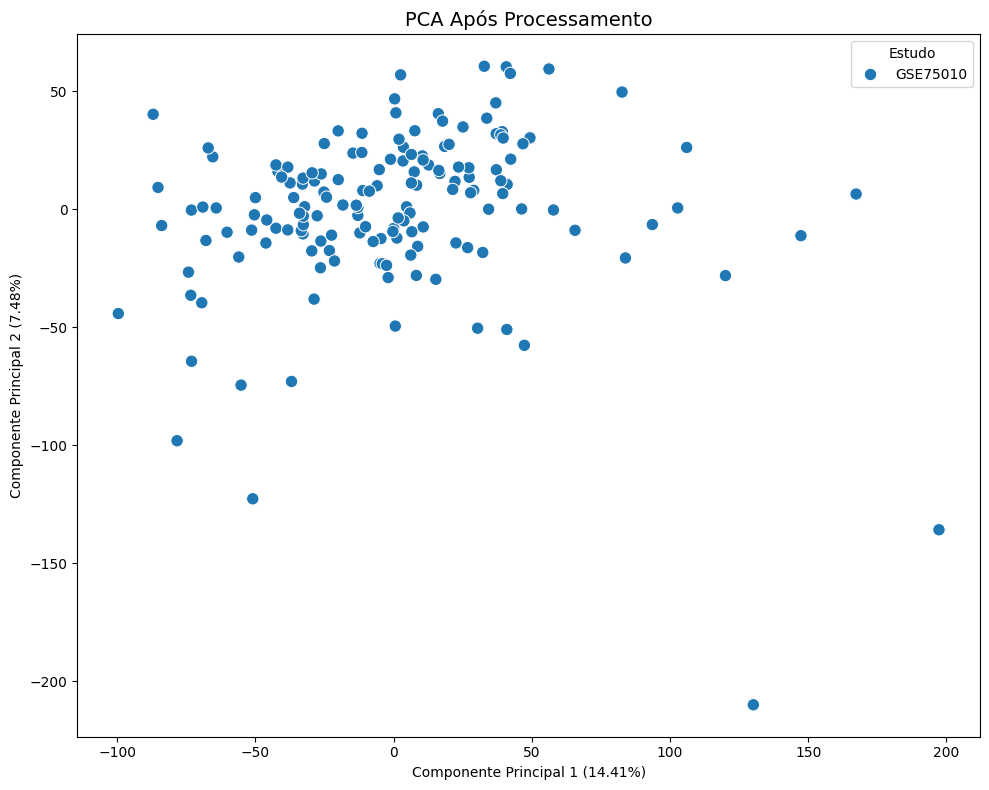


7. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA
  📥 Baixando arquivo GMT para 'Hallmark'...


2025-09-12 18:50:31,444 [WARNING] Found duplicated gene names, values averaged by gene names!


  🔬 Executando análise ssGSEA (GSVA)...
  ❌ Erro no GSVA: 'numpy.float64' object has no attribute 'upper'

8. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS
  GSVA falhou, o dataset final conterá apenas dados clínicos.
  Dimensões do dataset final (Hallmark): (157, 9)

9. 💾 SALVANDO DATASETS PROCESSADOS
  ✅ Datasets foram salvos no diretório 'output'.

10. 📊 ESTATÍSTICAS DESCRITIVAS DO DATASET FINAL
  Controles (0): 157
  Casos de PE (1): 0
  Idade Gestacional (semanas):
    Média: 0.0 ± 0.0
    Intervalo: 0.0 - 0.0

ANÁLISE ADICIONAL (EXEMPLO DE FLEXIBILIDADE)

 executando GSVA com o banco de dados 'KEGG'...
  📥 Baixando arquivo GMT para 'KEGG'...
  ❌ Erro no GSVA: 404 Client Error: Not Found for url: https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c2.cp.kegg.v2023.2.Hs.symbols.gmt

PIPELINE CONCLUÍDO COM SUCESSO! 🎉


In [ ]:
# =============================================================================
# 1. INSTALAÇÃO DE DEPENDÊNCIAS
# =============================================================================
!pip install GEOparse pandas numpy scikit-learn matplotlib seaborn gseapy requests --quiet

# =============================================================================
# 2. IMPORTAÇÕES
# =============================================================================
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import gseapy as gp
import requests
import os
import tempfile
import re
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 3. FUNÇÕES PARA AQUISIÇÃO E PRÉ-PROCESSAMENTO DE DADOS
# =============================================================================

def download_and_load_gse(gse_id, dest_dir="."):
    print(f"🔽 Processando {gse_id}...")
    try:
        gse = GEOparse.get_GEO(geo=gse_id, destdir=dest_dir, silent=True)
        print(f"✅ {gse_id} carregado com sucesso.")
        return gse
    except Exception as e:
        print(f"❌ Erro ao descarregar {gse_id}: {e}")
        return None

def extract_clinical_data(gse):
    pheno_data = []
    for gsm_name, gsm in gse.gsms.items():
        sample_data = {'gsm_id': gsm_name}
        sample_data.update(gsm.metadata)
        pheno_data.append(sample_data)
    return pd.DataFrame(pheno_data)

def extract_expression_data(gse):
    try:
        platform_id = list(gse.gpls.keys())[0]
        platform_table = gse.gpls[platform_id].table
        expr_matrix = gse.pivot_samples('VALUE')
        print(f"  Matriz de expressão original: {expr_matrix.shape[0]} linhas x {expr_matrix.shape[1]} colunas")

        if 'Gene Symbol' in platform_table.columns:
            print("  Mapeando IDs de sonda para símbolos de genes...")
            probe_to_gene = platform_table.set_index('ID')['Gene Symbol'].to_dict()
            expr_matrix.index = expr_matrix.index.map(lambda x: str(probe_to_gene.get(x, x)).split('///')[0].strip())

        expr_matrix.index = expr_matrix.index.astype(str)
        expr_matrix = expr_matrix[~expr_matrix.index.str.contains('^AFFX-')]
        expr_matrix = expr_matrix[(expr_matrix.index != '') & (expr_matrix.index != 'nan')]

        if expr_matrix.index.duplicated().any():
            print("  Resolvendo genes duplicados mantendo o de maior variância...")
            variances = expr_matrix.var(axis=1)
            expr_matrix['variance'] = variances
            expr_matrix = expr_matrix.loc[expr_matrix.groupby(expr_matrix.index)['variance'].idxmax()]
            expr_matrix = expr_matrix.drop(columns=['variance'])

        print(f"  Matriz de expressão final: {expr_matrix.shape[0]} genes x {expr_matrix.shape[1]} amostras")
        return expr_matrix
    except Exception as e:
        print(f"❌ Erro ao extrair dados de expressão: {e}")
        return None

def harmonize_clinical_data_gse75010(df):
    harmonized_data = []
    for index, row in df.iterrows():
        sample_data = {'sample_id': row['gsm_id'], 'study': 'GSE75010'}
        sample_chars = {}

        characteristics_list = row.get('characteristics_ch1', [])
        if isinstance(characteristics_list, list):
            for item in characteristics_list:
                parts = str(item).split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip().lower()
                    value = parts[1].strip()
                    sample_chars[key] = value

        status_text = sample_chars.get('disease state', '').lower()
        sample_data['pe_status'] = 1 if 'preeclampsia' in status_text else 0

        sample_data['gestational_age'] = pd.to_numeric(sample_chars.get('gestational age'), errors='coerce')
        sample_data['systolic_bp'] = pd.to_numeric(sample_chars.get('systolic bp'), errors='coerce')
        sample_data['diastolic_bp'] = pd.to_numeric(sample_chars.get('diastolic bp'), errors='coerce')
        sample_data['proteinuria'] = sample_chars.get('proteinuria')
        sample_data['uterine_artery_pi'] = pd.to_numeric(sample_chars.get('mean uterine artery pi'), errors='coerce')

        hellp = sample_chars.get('hellp syndrome', 'no').lower()
        sample_data['hellp_syndrome'] = 1 if hellp == 'yes' else 0

        sample_data['molecular_subtype'] = sample_chars.get('molecular subtype')
        harmonized_data.append(sample_data)

    return pd.DataFrame(harmonized_data)

def impute_missing_values(df, n_neighbors=5):
    df_imputed = df.copy()
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_cols: return df_imputed

    all_nan_cols = [col for col in numeric_cols if df[col].isnull().all()]
    cols_to_impute = [col for col in numeric_cols if col not in all_nan_cols and df[col].isnull().any()]

    if all_nan_cols:
        print(f"  ⚠️ Colunas completamente vazias preenchidas com 0: {all_nan_cols}")
        for col in all_nan_cols: df_imputed[col].fillna(0, inplace=True)

    if cols_to_impute:
        print(f"  🔍 Imputando valores parciais em: {cols_to_impute}")
        valid_samples_count = len(df[cols_to_impute].dropna())
        k = min(n_neighbors, valid_samples_count)
        if k > 1:
            imputer = KNNImputer(n_neighbors=k)
            df_imputed[cols_to_impute] = imputer.fit_transform(df_imputed[cols_to_impute])
        else:
            for col in cols_to_impute: df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)

    return df_imputed

def plot_pca(expression_df, batch_labels, title, ax=None):
    scaler = StandardScaler()
    expr_scaled = scaler.fit_transform(expression_df.T)
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(expr_scaled)
    pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=expression_df.columns)
    pc_df['Batch'] = batch_labels.values
    if ax is None: fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', hue='Batch', data=pc_df, s=80, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.legend(title='Estudo')
    return ax

def run_gsva(expression_df, gene_sets='Hallmark'):
    """
    Executa GSVA usando um banco de dados de vias selecionado.
    """
    try:
        df_gsva = expression_df.copy()
        df_gsva.index = df_gsva.index.str.upper()

        if df_gsva.index.duplicated().any():
            variances = df_gsva.var(axis=1)
            df_gsva['variance'] = variances
            df_gsva = df_gsva.loc[df_gsva.groupby(df_gsva.index)['variance'].idxmax()]
            df_gsva = df_gsva.drop(columns=['variance'])

        # --- CORREÇÃO: Dicionário com múltiplas opções restaurado ---
        gmt_urls = {
            'Hallmark': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
            'KEGG': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c2.cp.kegg.v2023.2.Hs.symbols.gmt',
            'GO_BP': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c5.go.bp.v2023.2.Hs.symbols.gmt'
        }

        if gene_sets not in gmt_urls:
            raise ValueError(f"Gene set '{gene_sets}' não reconhecido. Opções válidas: {list(gmt_urls.keys())}")

        print(f"  📥 Baixando arquivo GMT para '{gene_sets}'...")
        response = requests.get(gmt_urls[gene_sets])
        response.raise_for_status()

        with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.gmt') as tmp:
            tmp.write(response.text)
            gmt_file_path = tmp.name

        print("  🔬 Executando análise ssGSEA (GSVA)...")
        ss = gp.ssgsea(data=df_gsva,
                       gene_sets=gmt_file_path,
                       sample_norm_method='rank',
                       min_size=10, max_size=500,
                       outdir=None, verbose=False)
        os.unlink(gmt_file_path)

        gsva_scores = ss.res2d.set_index('Term').T
        gsva_scores.columns = [f"GSVA_{gene_sets}_{col.replace(' ', '_')}" for col in gsva_scores.columns]
        print(f"  ✅ GSVA com '{gene_sets}' concluído. {gsva_scores.shape[1]} vias calculadas.")
        return gsva_scores
    except Exception as e:
        print(f"  ❌ Erro no GSVA: {e}")
        return pd.DataFrame()

# =============================================================================
# 4. EXECUÇÃO PRINCIPAL DO PIPELINE
# =============================================================================
def main():
    print("=" * 70)
    print("FRAMEWORK COMPUTACIONAL PARA INVESTIGAÇÃO DE SUBTIPOS DE PRÉ-ECLÂMPSIA")
    print("=" * 70)

    print("\n1. 📥 DOWNLOAD DO DATASET GSE75010")
    gse_main = download_and_load_gse("GSE75010")
    if gse_main is None: return

    print("\n2. 📊 EXTRAÇÃO DE DADOS CLÍNICOS E DE EXPRESSÃO")
    clinical_df_raw = extract_clinical_data(gse_main)
    expression_df = extract_expression_data(gse_main)
    if expression_df is None: return

    print("\n3. 🔄 HARMONIZAÇÃO DE DADOS CLÍNICOS")
    clinical_harmonized = harmonize_clinical_data_gse75010(clinical_df_raw)
    print("  Colunas harmonizadas:", list(clinical_harmonized.columns))

    print("\n4. 🔍 IMPUTAÇÃO DE VALORES EM FALTA")
    clinical_imputed = impute_missing_values(clinical_harmonized)

    print("\n5. 📊 NORMALIZAÇÃO E FILTRAGEM DE DADOS DE EXPRESSÃO")
    gene_variance = expression_df.var(axis=1)
    threshold = np.percentile(gene_variance, 50)
    expression_filtered = expression_df.loc[gene_variance > threshold]
    print(f"  Genes após filtragem por variância: {expression_filtered.shape[0]}")

    if expression_filtered.max().max() > 50:
        expression_normalized = np.log2(expression_filtered + 1)
        print("  Transformação log2(x+1) aplicada.")
    else:
        expression_normalized = expression_filtered
        print("  Dados já parecem estar em escala logarítmica.")

    print("\n6. 📈 VISUALIZAÇÃO COM PCA")
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    batch_labels = pd.Series(['GSE75010'] * expression_df.shape[1], index=expression_df.columns)
    plot_pca(expression_normalized, batch_labels, 'PCA Após Processamento', ax)
    plt.tight_layout()
    plt.show()

    print("\n7. 🧪 ENGENHARIA DE CARACTERÍSTICAS COM GSVA")
    gsva_scores_hallmark = run_gsva(expression_normalized, gene_sets='Hallmark')

    print("\n8. 🧩 INTEGRAÇÃO FINAL DAS CARACTERÍSTICAS")
    clinical_for_merge = clinical_imputed.set_index('sample_id')
    final_features = pd.DataFrame()
    if not gsva_scores_hallmark.empty:
        common_samples = clinical_for_merge.index.intersection(gsva_scores_hallmark.index)
        print(f"  Amostras em comum para integração: {len(common_samples)}")
        final_features = clinical_for_merge.loc[common_samples].join(gsva_scores_hallmark.loc[common_samples], how='inner')
    else:
        print("  GSVA falhou, o dataset final conterá apenas dados clínicos.")
        final_features = clinical_for_merge
    print(f"  Dimensões do dataset final (Hallmark): {final_features.shape}")

    print("\n9. 💾 SALVANDO DATASETS PROCESSADOS")
    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    expression_normalized.to_csv(os.path.join(output_dir, 'GSE75010_expression_processed.csv'))
    clinical_imputed.to_csv(os.path.join(output_dir, 'GSE75010_clinical_processed.csv'), index=False)
    final_features.to_csv(os.path.join(output_dir, 'GSE75010_final_features_hallmark.csv'))
    print(f"  ✅ Datasets foram salvos no diretório '{output_dir}'.")

    print("\n10. 📊 ESTATÍSTICAS DESCRITIVAS DO DATASET FINAL")
    if not final_features.empty:
        if 'pe_status' in final_features.columns:
            pe_counts = final_features['pe_status'].value_counts()
            print(f"  Controles (0): {pe_counts.get(0, 0)}")
            print(f"  Casos de PE (1): {pe_counts.get(1, 0)}")
        if 'gestational_age' in final_features.columns and final_features['gestational_age'].notna().any():
            print(f"  Idade Gestacional (semanas):")
            print(f"    Média: {final_features['gestational_age'].mean():.1f} ± {final_features['gestational_age'].std():.1f}")
            print(f"    Intervalo: {final_features['gestational_age'].min():.1f} - {final_features['gestational_age'].max():.1f}")

    # --- Demonstração da flexibilidade ---
    print("\n" + "=" * 70)
    print("ANÁLISE ADICIONAL (EXEMPLO DE FLEXIBILIDADE)")
    print("=" * 70)
    print("\n executando GSVA com o banco de dados 'KEGG'...")
    gsva_scores_kegg = run_gsva(expression_normalized, gene_sets='KEGG')
    if not gsva_scores_kegg.empty:
        print(f"  Dimensões do GSVA KEGG: {gsva_scores_kegg.shape}")
        final_features_kegg = clinical_for_merge.join(gsva_scores_kegg, how='inner')
        final_features_kegg.to_csv(os.path.join(output_dir, 'GSE75010_final_features_kegg.csv'))
        print("  ✅ Arquivo com características KEGG salvo com sucesso.")

    print("\n" + "=" * 70)
    print("PIPELINE CONCLUÍDO COM SUCESSO! 🎉")
    print("=" * 70)

# =============================================================================
# 5. EXECUTAR O PIPELINE
# =============================================================================
if __name__ == "__main__":
    main()

# Download E ANÁLISES Datasets

In [ ]:
import GEOparse
import requests
import os

def download_required_datasets(output_dir="datasets"):
    """
    Baixa os datasets essenciais para a análise da pré-eclâmpsia.

    1. Dataset GSE75010 do NCBI GEO.
    2. Arquivos de referência Hallmark, KEGG e GO_BP (GMT) do Broad Institute.
    """
    print("=" * 50)
    print("INICIANDO DOWNLOAD DOS DATASETS")
    print("=" * 50)

    os.makedirs(output_dir, exist_ok=True)
    print(f"Os arquivos serão salvos em: '{os.path.abspath(output_dir)}'")

    # --- 1. Baixar dados do GEO ---
    gse_id = "GSE75010"
    print(f"\n[1/4] Baixando dataset {gse_id} do GEO...")
    try:
        GEOparse.get_GEO(geo=gse_id, destdir=output_dir, silent=False)
        print(f"✅ Download do {gse_id} concluído.")
    except Exception as e:
        print(f"❌ Erro ao baixar {gse_id}: {e}")

    # --- 2. Baixar arquivos GMT ---
    gmt_files = {
        'Hallmark': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
        'KEGG': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c2.cp.kegg.v2023.2.Hs.symbols.gmt',
        'GO_BP': 'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c5.go.bp.v2023.2.Hs.symbols.gmt'
    }

    for i, (name, url) in enumerate(gmt_files.items()):
        filename = f"{name.lower()}_gene_sets.gmt"
        filepath = os.path.join(output_dir, filename)

        print(f"\n[{i+2}/4] Baixando arquivo de referência '{name}' GMT...")
        try:
            response = requests.get(url)
            response.raise_for_status()

            with open(filepath, 'w') as f:
                f.write(response.text)

            print(f"✅ Arquivo '{name}' salvo em: '{filepath}'")
        except Exception as e:
            print(f"❌ Erro ao baixar '{name}': {e}")

    print("\n" + "=" * 50)
    print("DOWNLOADS CONCLUÍDOS!")
    print("=" * 50)

if __name__ == "__main__":
    download_required_datasets()

INICIANDO DOWNLOAD DOS DATASETS
Os arquivos serão salvos em: '/content/datasets'

[1/4] Baixando dataset GSE75010 do GEO...
✅ Download do GSE75010 concluído.

[2/4] Baixando arquivo de referência 'Hallmark' GMT...
✅ Arquivo 'Hallmark' salvo em: 'datasets/hallmark_gene_sets.gmt'

[3/4] Baixando arquivo de referência 'KEGG' GMT...
❌ Erro ao baixar 'KEGG': 404 Client Error: Not Found for url: https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/c2.cp.kegg.v2023.2.Hs.symbols.gmt

[4/4] Baixando arquivo de referência 'GO_BP' GMT...
✅ Arquivo 'GO_BP' salvo em: 'datasets/go_bp_gene_sets.gmt'

DOWNLOADS CONCLUÍDOS!


In [ ]:
import pandas as pd
import numpy as np
import GEOparse
import os
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# FUNÇÕES DE PROCESSAMENTO (COPIADAS DO NOTEBOOK PRINCIPAL)
# =============================================================================

def harmonize_clinical_data_gse75010(df):
    """
    Mapeia as colunas de metadados brutos para um formato limpo e padronizado.
    """
    harmonized_data = []
    for index, row in df.iterrows():
        # Usa o 'gsm_id' que agora está presente no DataFrame
        sample_data = {'sample_id': row['gsm_id']}
        sample_chars = {}

        # O valor de 'characteristics_ch1' é uma lista de strings
        characteristics_list = row.get('characteristics_ch1', [])
        if isinstance(characteristics_list, list):
            for item in characteristics_list:
                parts = str(item).split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip().lower()
                    value = parts[1].strip()
                    sample_chars[key] = value

        # Mapeamento explícito das chaves encontradas para as colunas padronizadas
        status_text = sample_chars.get('disease state', '').lower()
        sample_data['pe_status'] = 1 if 'preeclampsia' in status_text else 0
        sample_data['gestational_age'] = pd.to_numeric(sample_chars.get('gestational age'), errors='coerce')
        sample_data['systolic_bp'] = pd.to_numeric(sample_chars.get('systolic bp'), errors='coerce')
        sample_data['diastolic_bp'] = pd.to_numeric(sample_chars.get('diastolic bp'), errors='coerce')
        sample_data['proteinuria'] = sample_chars.get('proteinuria')
        sample_data['uterine_artery_pi'] = pd.to_numeric(sample_chars.get('mean uterine artery pi'), errors='coerce')
        hellp = sample_chars.get('hellp syndrome', 'no').lower()
        sample_data['hellp_syndrome'] = 1 if hellp == 'yes' else 0
        sample_data['molecular_subtype'] = sample_chars.get('molecular subtype')
        harmonized_data.append(sample_data)

    return pd.DataFrame(harmonized_data)

def extract_expression_data(gse):
    """
    Extrai a matriz de expressão do objeto GSE.
    """
    try:
        expr_matrix = gse.pivot_samples('VALUE')
        return expr_matrix
    except Exception:
        return pd.DataFrame()

# =============================================================================
# FUNÇÃO DE ANÁLISE
# =============================================================================

def analyze_dataframe(df, df_name):
    """
    Executa uma análise completa em um DataFrame e imprime os resultados.
    """
    print("\n" + "=" * 70)
    print(f"🔎 ANÁLISE DO DATAFRAME: {df_name}")
    print("=" * 70)

    if df.empty:
        print("DataFrame está vazio. Nenhuma análise a ser feita.")
        return

    # 1. Quantidade de Linhas
    num_rows = len(df)
    print(f"\nTotal de Linhas: {num_rows}")

    # 2. Lista de Colunas
    columns = df.columns.tolist()
    print(f"\nColunas ({len(columns)}):")
    print(columns)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    # 3. Colunas com Todos os Dados Iguais a 0
    if numeric_cols:
        all_zero_cols = [col for col in numeric_cols if (df[col] == 0).all()]
        if all_zero_cols:
            print("\nColunas com Todos os Valores Iguais a 0:")
            print(all_zero_cols)
        else:
            print("\nNenhuma coluna com todos os valores iguais a 0.")

    # 4. Valor que Mais se Repete (Moda) em Cada Coluna
    print("\nValor Mais Frequente (Moda) por Coluna:")
    modes = df.mode().iloc[0]
    for col, mode_val in modes.items():
        print(f"  - {col}: {mode_val}")

    # 5. Média dos Valores de Cada Coluna Numérica
    if numeric_cols:
        print("\nMédia dos Valores por Coluna Numérica:")
        means = df[numeric_cols].mean()
        for col, mean_val in means.items():
            if pd.notna(mean_val):
                print(f"  - {col}: {mean_val:.4f}")
            else:
                print(f"  - {col}: Vazia (NaN)")
    else:
        print("\nNenhuma coluna numérica para calcular a média.")

# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main_analysis(data_dir="datasets"):
    """
    Função principal para carregar os dados baixados e analisá-los.
    """
    print("Iniciando script de análise de dados...")

    geo_file = None
    for f in os.listdir(data_dir):
        if f.startswith("GSE75010") and f.endswith(".soft.gz"):
            geo_file = os.path.join(data_dir, f)
            break

    if not geo_file:
        print(f"ERRO: Arquivo GSE75010_family.soft.gz não encontrado no diretório '{data_dir}'")
        return

    print(f"Carregando dados do arquivo local: {geo_file}")
    gse = GEOparse.get_GEO(filepath=geo_file)

    # --- ETAPA DE INSPEÇÃO DINÂMICA ---
    print("\n" + "=" * 70)
    print("🔬 INSPECIONANDO METADADOS BRUTOS (PRIMEIRA AMOSTRA)")
    print("=" * 70)
    first_sample_name = list(gse.gsms.keys())[0]
    first_sample_metadata = gse.gsms[first_sample_name].metadata
    print(f"Etiquetas de metadados encontradas em '{first_sample_name}':")
    for key, value in first_sample_metadata.items():
        # Imprime apenas as chaves da lista 'characteristics_ch1' que serão usadas
        if key == 'characteristics_ch1' and isinstance(value, list):
            print(f"  - Campo '{key}':")
            for item in value:
                print(f"    - \"{item}\"")
        else:
            print(f"  - Campo '{key}' (valor: {value[0]})")
    print("=" * 70)


    # --- CRIAÇÃO E PROCESSAMENTO DOS DATAFRAMES ---

    # CORREÇÃO: Construir o DataFrame incluindo o gsm_id
    clinical_raw_data = []
    for gsm_name, gsm_obj in gse.gsms.items():
        metadata = gsm_obj.metadata
        metadata['gsm_id'] = gsm_name  # Adiciona o ID ao dicionário
        clinical_raw_data.append(metadata)
    clinical_raw_df = pd.DataFrame(clinical_raw_data)

    # Processa os dados brutos para o formato final limpo
    clinical_processed_df = harmonize_clinical_data_gse75010(clinical_raw_df)
    expression_df = extract_expression_data(gse)

    # --- ANÁLISE DOS DATAFRAMES PROCESSADOS ---
    analyze_dataframe(clinical_processed_df, "Dados Clínicos Processados")
    analyze_dataframe(expression_df, "Dados de Expressão Gênica")

    print("\n" + "=" * 70)
    print("Análise Concluída!")
    print("=" * 70)

if __name__ == "__main__":
    main_analysis()

Iniciando script de análise de dados...
Carregando dados do arquivo local: datasets/GSE75010_family.soft.gz

🔬 INSPECIONANDO METADADOS BRUTOS (PRIMEIRA AMOSTRA)
Etiquetas de metadados encontradas em 'GSM1940492':
  - Campo 'title' (valor: PE-Term-SGA, rep1)
  - Campo 'geo_accession' (valor: GSM1940492)
  - Campo 'status' (valor: Public on May 10 2016)
  - Campo 'submission_date' (valor: Nov 13 2015)
  - Campo 'last_update_date' (valor: Oct 02 2018)
  - Campo 'type' (valor: RNA)
  - Campo 'channel_count' (valor: 1)
  - Campo 'source_name_ch1' (valor: Human placenta from PE-Term-SGA pregnancy)
  - Campo 'organism_ch1' (valor: Homo sapiens)
  - Campo 'taxid_ch1' (valor: 9606)
  - Campo 'characteristics_ch1':
    - "diagnosis: PE"
    - "tissue: Placenta"
    - "maternal age: 39"
    - "maternal bmi: NA"
    - "maternal ethnicity: Caucasian"
    - "maternal blood type: A"
    - "previous nulliparity: Yes"
    - "previous miscarriage: Yes"
    - "previous hypertensive pregnancy: NA"
    - "